# Analysis of whole-brain scRNAseq data



## Download ABC data

In [ ]:
# !pip install -U git+https://github.com/alleninstitute/abc_atlas_access

  Cloning https://github.com/alleninstitute/abc_atlas_access to /tmp/pip-req-build-u5rwrx__
  Running command git clone --filter=blob:none --quiet https://github.com/alleninstitute/abc_atlas_access /tmp/pip-req-build-u5rwrx__
  Resolved https://github.com/alleninstitute/abc_atlas_access to commit e4a6696b44788088119238965f766db640b7ebb2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.7 MB/s eta 0:00:00
  Using cached pluggy-1.5.0-py3-none-any.whl.metadata (4.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 67.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.3/342.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 MB 58.5 MB/s eta 0:00:0000:0100:01
Using cached pluggy-1.5.0-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.2 MB/s eta 0:00:0

In [1]:
import sys
import os
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

sc.settings.set_figure_params(dpi=150, facecolor='white')
sc.settings.n_jobs = 30

# Palette
from matplotlib import pyplot as plt, cm as mpl_cm
from cycler import cycler
palette=cycler(color=mpl_cm.tab20.colors)
wd = '/home/davi/Bioinfo/ObesityLab/Samson/WholeBrain/'

In [2]:
download_base = Path('/home/davi/Bioinfo/ObesityLab/Samson/')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20241130/manifest.json'

In [3]:
abc_cache.list_directories

['Allen-CCF-2020',
 'MERFISH-C57BL6J-638850',
 'MERFISH-C57BL6J-638850-CCF',
 'MERFISH-C57BL6J-638850-imputed',
 'MERFISH-C57BL6J-638850-sections',
 'WHB-10Xv3',
 'WHB-taxonomy',
 'WMB-10X',
 'WMB-10XMulti',
 'WMB-10Xv2',
 'WMB-10Xv3',
 'WMB-neighborhoods',
 'WMB-taxonomy',
 'Zeng-Aging-Mouse-10Xv3',
 'Zeng-Aging-Mouse-WMB-taxonomy',
 'Zhuang-ABCA-1',
 'Zhuang-ABCA-1-CCF',
 'Zhuang-ABCA-2',
 'Zhuang-ABCA-2-CCF',
 'Zhuang-ABCA-3',
 'Zhuang-ABCA-3-CCF',
 'Zhuang-ABCA-4',
 'Zhuang-ABCA-4-CCF']

In [4]:
gene_df = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene')
gene_df

,gene_identifier,gene_symbol,name,mapped_ncbi_identifier,comment
0,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,NCBIGene:497097,NaN
1,ENSMUSG00000089699,Gm1992,predicted gene 1992,NaN,NaN
2,ENSMUSG00000102331,Gm19938,"predicted gene, 19938",NaN,NaN
3,ENSMUSG00000102343,Gm37381,"predicted gene, 37381",NaN,NaN
4,ENSMUSG00000025900,Rp1,retinitis pigmentosa 1 (human),NCBIGene:19888,NaN
...,...,...,...,...,...
32280,ENSMUSG00000095523,AC124606.1,PRAME family member 8-like,NCBIGene:100038995,no expression
32281,ENSMUSG00000095475,AC133095.2,uncharacterized LOC545763,NCBIGene:545763,no expression
32282,ENSMUSG00000094855,AC133095.1,uncharacterized LOC620639,NCBIGene:620639,no expression
32283,ENSMUSG00000095019,AC234645.1,NaN,NaN,no expression


In [5]:
abc_cache.list_data_files('WMB-10Xv3')

['WMB-10Xv3-CB/log2',
 'WMB-10Xv3-CB/raw',
 'WMB-10Xv3-CTXsp/log2',
 'WMB-10Xv3-CTXsp/raw',
 'WMB-10Xv3-HPF/log2',
 'WMB-10Xv3-HPF/raw',
 'WMB-10Xv3-HY/log2',
 'WMB-10Xv3-HY/raw',
 'WMB-10Xv3-Isocortex-1/log2',
 'WMB-10Xv3-Isocortex-1/raw',
 'WMB-10Xv3-Isocortex-2/log2',
 'WMB-10Xv3-Isocortex-2/raw',
 'WMB-10Xv3-MB/log2',
 'WMB-10Xv3-MB/raw',
 'WMB-10Xv3-MY/log2',
 'WMB-10Xv3-MY/raw',
 'WMB-10Xv3-OLF/log2',
 'WMB-10Xv3-OLF/raw',
 'WMB-10Xv3-P/log2',
 'WMB-10Xv3-P/raw',
 'WMB-10Xv3-PAL/log2',
 'WMB-10Xv3-PAL/raw',
 'WMB-10Xv3-STR/log2',
 'WMB-10Xv3-STR/raw',
 'WMB-10Xv3-TH/log2',
 'WMB-10Xv3-TH/raw']

In [ ]:
TenXv3 = abc_cache.get_directory_data('WMB-10Xv3')
print("10X files:\n\t", TenXv3)

/home/davi/intelpython3/lib/python3.9/site-packages/abc_atlas_access/abc_atlas_cache/abc_project_cache.py:385: LargeDataSizeWarning: WMB-10Xv3 contains a significant amount of data.Continue this download only if you are sure you have enough space on your system.

	Total directory size = 176.41 GB


  warnings.warn(
WMB-10Xv3-CB-log2.h5ad: 100%|██████████| 5.61G/5.61G [15:45<00:00, 5.93MMB/s]    
WMB-10Xv3-CB-raw.h5ad: 100%|██████████| 5.61G/5.61G [15:06<00:00, 6.19MMB/s]    
WMB-10Xv3-CTXsp-log2.h5ad: 100%|██████████| 3.28G/3.28G [10:03<00:00, 5.43MMB/s]    
WMB-10Xv3-CTXsp-raw.h5ad: 100%|██████████| 3.28G/3.28G [09:20<00:00, 5.85MMB/s]    
WMB-10Xv3-HPF-log2.h5ad: 100%|██████████| 7.41G/7.41G [18:29<00:00, 6.68MMB/s]     
WMB-10Xv3-HPF-raw.h5ad: 100%|██████████| 7.41G/7.41G [21:03<00:00, 5.86MMB/s]    
WMB-10Xv3-HY-log2.h5ad: 100%|██████████| 7.25G/7.25G [21:19<00:00, 5.66MMB/s]    
WMB-10Xv3-HY-raw.h5ad: 100%|██████████| 7.25G/7.25G [21:03<00:00, 5.74MMB/s]    
WMB-10Xv3-Isocortex-1-

OSError: [Errno 28] No space left on device

WMB-10Xv3-OLF-raw.h5ad:  19%|█▉        | 588M/3.11G [02:16<07:13, 5.83MMB/s]

## Download Metadata

In [ ]:
abc_cache.list_metadata_files('WMB-10X')


['cell_metadata',
 'cell_metadata_with_cluster_annotation',
 'example_genes_all_cells_expression',
 'gene',
 'region_of_interest_metadata']

In [ ]:
meta = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='cell_metadata_with_cluster_annotation')
meta

/home/davi/intelpython3/lib/python3.9/site-packages/abc_atlas_access/abc_atlas_cache/abc_project_cache.py:429: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **kwargs)


,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
0,GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
1,AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
2,AACACACGTTGCTTGA-410_B05,AACACACGTTGCTTGA,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
3,CACAGATAGAGGCGGA-410_A05,CACAGATAGAGGCGGA,410_A05,L8TX_201029_01_A10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
4,AAAGTGAAGCATTTCG-410_B05,AAAGTGAAGCATTTCG,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4042971,GTGTGAGCAAACGCGA-1350_C05,GTGTGAGCAAACGCGA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,...,278 NLL Gata3 Gly-Gaba,1074 NLL Gata3 Gly-Gaba_1,4804 NLL Gata3 Gly-Gaba_1,#820e57,#72195a,#E57300,#a4fcb2,#C7CC7A,25,#CC5CB0
4042972,TTAGCAATCCCTGTTA-1350_C05,TTAGCAATCCCTGTTA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,...,157 RN Spp1 Glut,0682 RN Spp1 Glut_1,2761 RN Spp1 Glut_1,#2B93DF,#007200,#FF514D,#BA1FCC,#3DCC44,25,#CC5CB0
4042973,TTTGGCTGTCGCGCAA-1350_C05,TTTGGCTGTCGCGCAA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,...,278 NLL Gata3 Gly-Gaba,1076 NLL Gata3 Gly-Gaba_3,4806 NLL Gata3 Gly-Gaba_3,#820e57,#72195a,#E57300,#76CC00,#FF00CA,25,#CC5CB0
4042974,ATCCACCTCACAGACT-1320_B04,ATCCACCTCACAGACT,1320_B04,L8XR_220630_02_B10,WMB-10XMulti,cell,NaN,10xRSeq_Mult,OLF,C57BL6J-625156,...,278 NLL Gata3 Gly-Gaba,1076 NLL Gata3 Gly-Gaba_3,4806 NLL Gata3 Gly-Gaba_3,#820e57,#72195a,#E57300,#76CC00,#FF00CA,13,#FF7373


In [13]:
meta.columns

Index(['cell_label', 'cell_barcode', 'barcoded_cell_sample_label',
       'library_label', 'feature_matrix_label', 'entity',
       'brain_section_label', 'library_method', 'region_of_interest_acronym',
       'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y',
       'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype',
       'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color',
       'supertype_color', 'cluster_color', 'region_of_interest_order',
       'region_of_interest_color'],
      dtype='object')

## Analysis:

### Setup

### Read data, merge and QC

In [3]:
def read_and_sequentially_concatenate_h5ad(directory):
    h5ad_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.h5ad')]
    if not h5ad_files:
        raise ValueError("No .h5ad files found.")
    
    combined_adata = None
    for file in h5ad_files:
        current_adata = sc.read(file)
        if combined_adata is None:
            combined_adata = current_adata
        else:
            combined_adata = sc.concat([combined_adata, current_adata], axis=0, join='outer')
            del current_adata
            gc.collect()
    
    return combined_adata

In [4]:
adata = read_and_sequentially_concatenate_h5ad(wd + 'data')

/home/davi/intelpython3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/davi/intelpython3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/davi/intelpython3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/davi/intelpython3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/davi/intelpython3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.re

In [14]:
adata

AnnData object with n_obs × n_vars = 2349544 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression'
    var: 'gene_name'
    uns: 'coexpression_colors', 'log1p'

In [16]:
adata.var

,gene_name
gene_id,
Xkr4,Xkr4
Gm1992,Gm1992
Gm19938,Gm19938
Gm37381,Gm37381
Rp1,Rp1
...,...
LOC100038995,LOC100038995
LOC545763,LOC545763
LOC620639,LOC620639


In [17]:
adata.obs

,cell_barcode,library_label,anatomical_division_label,coexpression,class
cell_label,,,,,
GTTGCGGCACTCCTTG-191_A01,GTTGCGGCACTCCTTG,L8TX_191217_01_G06,CB,No Expression,27 MY GABA
TCATTTGCAGAAGCTG-191_A01,TCATTTGCAGAAGCTG,L8TX_191217_01_G06,CB,No Expression,27 MY GABA
TTGTGGAAGTTACGGG-193_B01,TTGTGGAAGTTACGGG,L8TX_191217_01_E07,CB,No Expression,27 MY GABA
CATCCCACATGACCCG-221.2_B01,CATCCCACATGACCCG,L8TX_200220_01_H08,CB,No Expression,27 MY GABA
GCCTGTTCATCTCATT-191_B01,GCCTGTTCATCTCATT,L8TX_191217_01_H06,CB,No Expression,27 MY GABA
...,...,...,...,...,...
TTTGTTGGTCAACATC-542_A04,TTTGTTGGTCAACATC,L8TX_210226_01_D12,MY,Single Gene Expression,34 Immune
TTTGTTGGTCAGGAGT-504_A01,TTTGTTGGTCAGGAGT,L8TX_210128_01_G04,MY,No Expression,33 Vascular
TTTGTTGGTTCCACGG-542_A04,TTTGTTGGTTCCACGG,L8TX_210226_01_D12,MY,No Expression,33 Vascular


In [19]:
meta

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AACACACGTTGCTTGA-410_B05,AACACACGTTGCTTGA,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
CACAGATAGAGGCGGA-410_A05,CACAGATAGAGGCGGA,410_A05,L8TX_201029_01_A10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AAAGTGAAGCATTTCG-410_B05,AAAGTGAAGCATTTCG,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGTGAGCAAACGCGA-1350_C05,GTGTGAGCAAACGCGA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,wt/wt,...,278 NLL Gata3 Gly-Gaba,1074 NLL Gata3 Gly-Gaba_1,4804 NLL Gata3 Gly-Gaba_1,#820e57,#72195a,#E57300,#a4fcb2,#C7CC7A,25,#CC5CB0
TTAGCAATCCCTGTTA-1350_C05,TTAGCAATCCCTGTTA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,wt/wt,...,157 RN Spp1 Glut,0682 RN Spp1 Glut_1,2761 RN Spp1 Glut_1,#2B93DF,#007200,#FF514D,#BA1FCC,#3DCC44,25,#CC5CB0
TTTGGCTGTCGCGCAA-1350_C05,TTTGGCTGTCGCGCAA,1350_C05,L8XR_220728_01_A05,WMB-10XMulti,cell,NaN,10xRSeq_Mult,MB,C57BL6J-641405,wt/wt,...,278 NLL Gata3 Gly-Gaba,1076 NLL Gata3 Gly-Gaba_3,4806 NLL Gata3 Gly-Gaba_3,#820e57,#72195a,#E57300,#76CC00,#FF00CA,25,#CC5CB0


In [18]:
meta = meta.set_index('cell_label')
meta

KeyError: "None of ['cell_label'] are in the columns"

In [20]:
adata = adata[adata.obs.index.isin(meta.index)]
adata

View of AnnData object with n_obs × n_vars = 2341350 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression', 'class'
    var: 'gene_name'
    uns: 'coexpression_colors', 'log1p'

In [21]:
# Subset `meta` to only cells present in `adata`
meta_subset = meta[meta.index.isin(adata.obs.index)]

# Keep only required columns
meta_subset = meta_subset[['neurotransmitter', 'class', 'subclass', 'supertype', 'cluster']]

meta_subset

,neurotransmitter,class,subclass,supertype,cluster
cell_label,,,,,
GCGAGAAGTTAAGGGC-410_B05,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
AATGGCTCAGCTCCTT-411_B06,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
AACACACGTTGCTTGA-410_B05,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
CACAGATAGAGGCGGA-410_A05,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
AAAGTGAAGCATTTCG-410_B05,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
...,...,...,...,...,...
TTTGTTGTCTCACTCG-424_C02,NaN,34 Immune,334 Microglia NN,1194 Microglia NN_1,5312 Microglia NN_1
TTTGTTGTCTCCATAT-393_C05,NaN,34 Immune,334 Microglia NN,1194 Microglia NN_1,5312 Microglia NN_1
TTTGTTGTCTCTCGCA-417_C03,NaN,34 Immune,334 Microglia NN,1194 Microglia NN_1,5312 Microglia NN_1


In [ ]:
adata.obs['class'] = meta_subset.loc[adata.obs.index, 'class']
adata.obs

/tmp/ipykernel_503483/1952829576.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['class'] = meta_subset.loc[adata.obs.index, 'class']


In [ ]:
del meta, meta_subset
gc.collect()

In [ ]:
sc.pp.filter_genes(adata, min_cells=10)

In [23]:
adata

View of AnnData object with n_obs × n_vars = 1886818 × 29474
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression', 'n_genes_by_counts', 'total_counts'
    var: 'gene_name', 'gene_full_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'coexpression_colors', 'log1p', 'library_label_colors'

## Write / Read

In [ ]:
adata.write_h5ad(wd + "WholeBrain_10Xv3_compressed.h5ad", compression="gzip", compression_opts=9)

In [ ]:
adata = sc.read_h5ad(wd + "WholeBrain_10Xv3_compressed.h5ad")
adata

AnnData object with n_obs × n_vars = 2349544 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression'
    var: 'gene_name'
    uns: 'coexpression_colors', 'log1p'

### Normalization

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

### Plot co-expression

In [ ]:

def calculate_coexpression_percentage(adata, gene1, gene2, threshold=0.5):
    # Calculate co-expression percentage
    gene1_expressed = adata[:, gene1].X.toarray() > threshold
    coexpression_cells = (adata[:, gene1].X.toarray() > threshold) & (adata[:, gene2].X.toarray() > threshold)
    total_cells = adata.shape[0]
    coexpression_percentage = (coexpression_cells.sum() / gene1_expressed.sum()) * 100
    return coexpression_percentage

def plot_coexpression_percentage(adata, gene1, gene2, threshold=0.5, ax=None):
    # Calculate co-expression percentage
    coexpression_percentage = calculate_coexpression_percentage(adata, gene1, gene2, threshold, plot_legend=True)

    # Add a temporary column to adata.obs for coloring
    gene1_expressed = adata[:, gene1].X.toarray() > threshold
    gene2_expressed = adata[:, gene2].X.toarray() > threshold
    #gene2_coexpressed = gene1_expressed.raw.to_adata()[:, gene2].X.toarray() > threshold
    adata.obs['coexpression'] = pd.Categorical(
        ['Co-expression' if (x & y) else 'Single Gene Expression' if (x | y) else 'No Expression' for x, y in zip(gene1_expressed, gene2_expressed)]
    )

    # Define colors for each category
    cmap = {'Co-expression': '#ad0303', 'No Expression': 'grey', 'Single Gene Expression': '#0350ad'}

    # Plot using scanpy
    sc.pl.scatter(adata, x=gene1, y=gene2, color='coexpression', size=15, title=f'Co-expression of {gene1} and {gene2}', use_raw=False, ax=ax, palette=cmap.values(), show=False)

    # Remove gridlines
    ax.grid(False)

    # Add dotted grey lines at threshold value
    ax.axvline(x=threshold, color='grey', linestyle='--')
    ax.axhline(y=threshold, color='grey', linestyle='--')

    # Calculate and plot the percentage of cells expressing each gene
    gene1_expression_percentage = (adata[:, gene1].X.toarray() > threshold).mean() * 100
    gene2_expression_percentage = (adata[:, gene2].X.toarray() > threshold).mean() * 100
    
    if plot_legend:
        ax.legend(title=f'Gene Expression (Threshold={threshold})')
        ax.legend(handles=[
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0350ad', markersize=10, label=f'{gene1}+ ({gene1_expression_percentage:.2f}%)'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0350ad', markersize=10, label=f'{gene2}+ ({gene2_expression_percentage:.2f}%)'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ad0303', markersize=10, label=f'{gene2}+/{gene1}+ ({coexpression_percentage:.2f}%)'),
        ], loc='best')



TypeError: calculate_coexpression_percentage() got an unexpected keyword argument 'plot_legend'

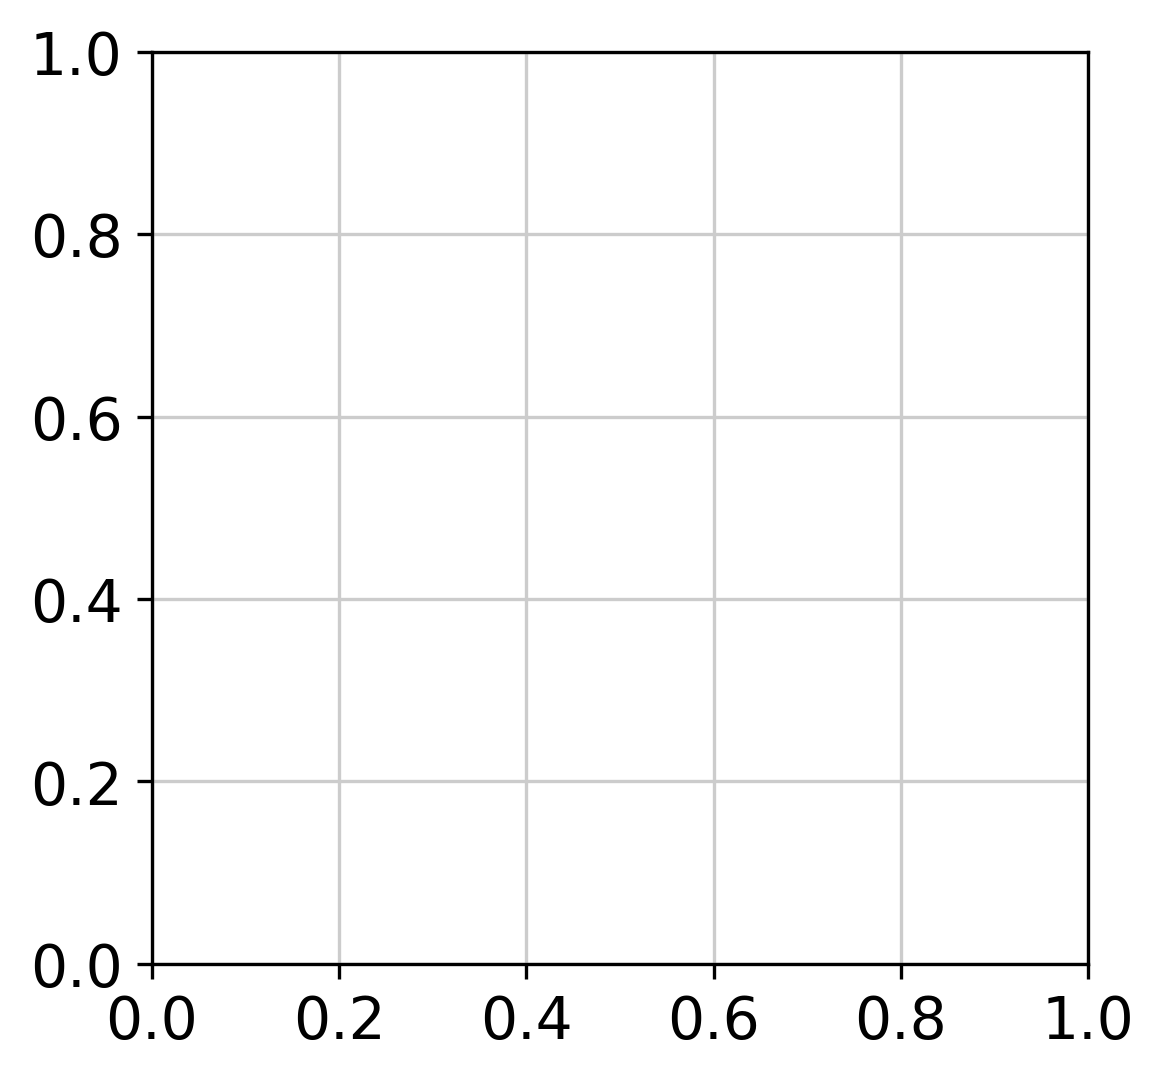

In [14]:
fig, ax = plt.subplots()
plot_coexpression_percentage(adata, 'Th', 'Adrb2', threshold=0.1, ax=ax)
plt.show()

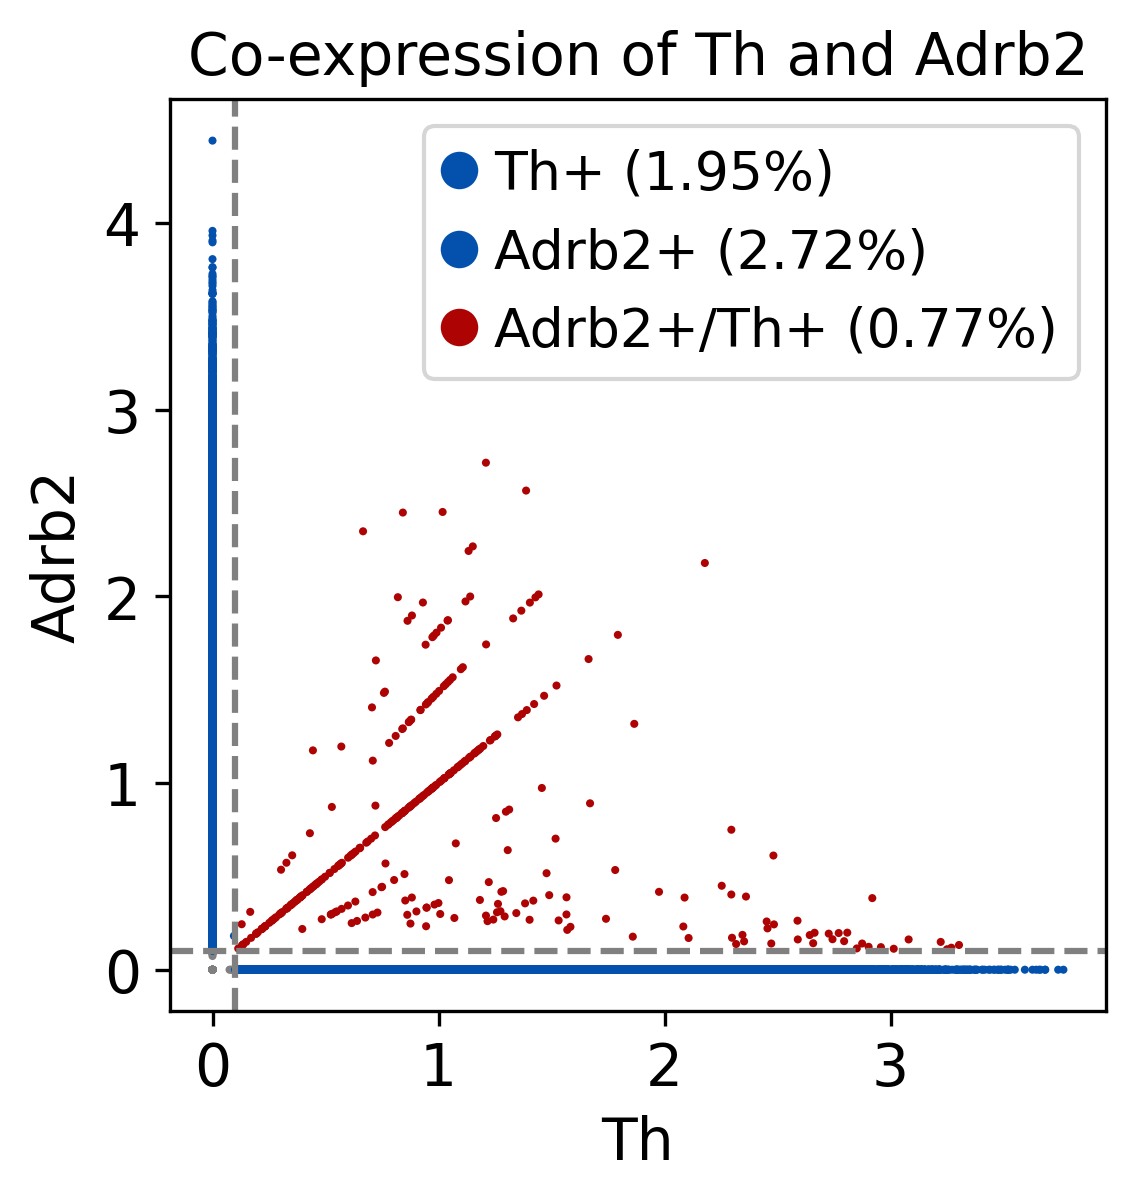

In [13]:
# Example usage:
fig, ax = plt.subplots()
plot_coexpression_percentage(adata, 'Th', 'Adrb2', threshold=0.1, ax=ax)
plt.show()


In [ ]:
def filter_double_positive(adata, gene1, gene2, threshold=0.5):
    if gene1 not in adata.var_names or gene2 not in adata.var_names:
        raise ValueError(f"One or both genes ({gene1}, {gene2}) not found in adata.var_names.")

    # Extract sparse matrix columns for the genes
    gene1_expr = adata[:, gene1].X
    gene2_expr = adata[:, gene2].X
    
    # Logical mask for both conditions
    mask = (gene1_expr > threshold).multiply(gene2_expr > threshold)
    
    # Subset AnnData
    return adata[mask.toarray().flatten()]


In [17]:
double_positive = filter_double_positive(adata, 'Th', 'Adrb2', threshold=0.5)
double_positive

View of AnnData object with n_obs × n_vars = 187 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression'
    var: 'gene_name'
    uns: 'log1p', 'coexpression_colors'

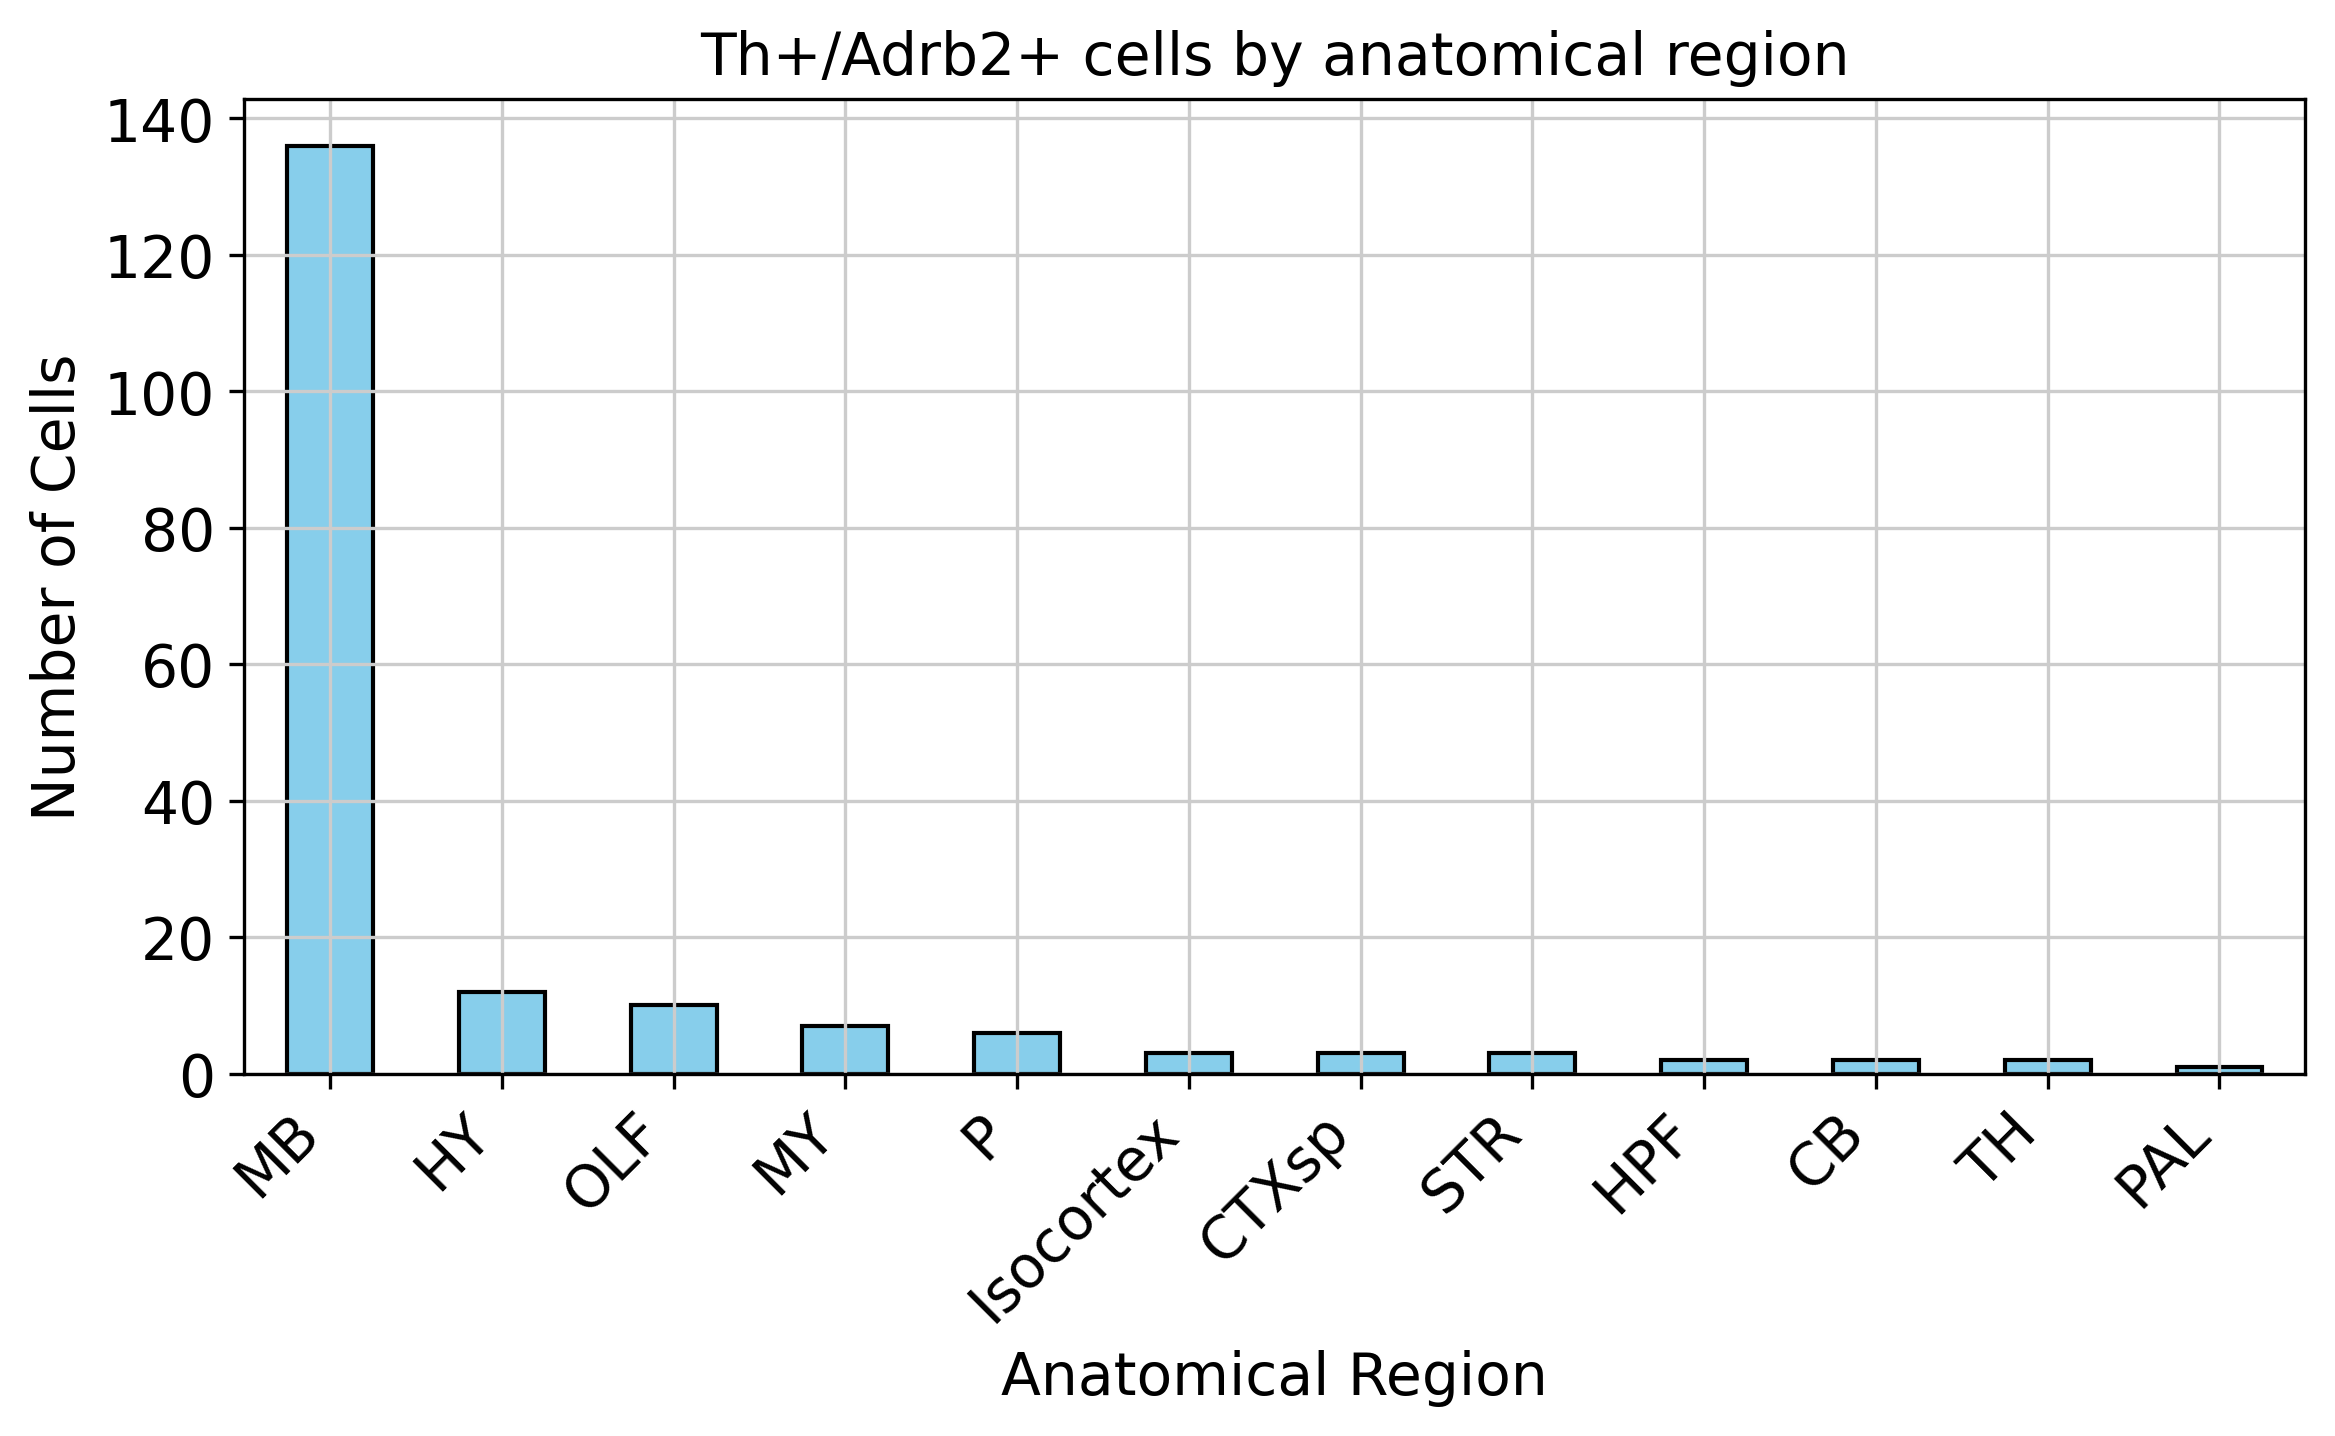

In [18]:
counts = double_positive.obs['anatomical_division_label'].value_counts()
counts.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8, 5))
plt.title(f"Th+/Adrb2+ cells by anatomical region")
plt.ylabel("Number of Cells")
plt.xlabel("Anatomical Region")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
adata.obs

,cell_barcode,library_label,anatomical_division_label,coexpression,n_genes_by_counts,total_counts
cell_label,,,,,,
GCCTGTTCATCTCATT-191_B01,GCCTGTTCATCTCATT,L8TX_191217_01_H06,CB,No Expression,6992,5884.309082
TCTATACTCTTGGGCG-221.2_A01,TCTATACTCTTGGGCG,L8TX_200220_01_G08,CB,No Expression,6543,5833.497070
AGTAGCTGTGGTAATA-221.2_A01,AGTAGCTGTGGTAATA,L8TX_200220_01_G08,CB,No Expression,7024,5994.923828
TTCCTCTCAGAAACCG-221.2_A01,TTCCTCTCAGAAACCG,L8TX_200220_01_G08,CB,No Expression,7945,5945.768555
TCCTCCCCAAATTGCC-213.2_B01,TCCTCCCCAAATTGCC,L8TX_200206_01_A03,CB,No Expression,7006,5917.798828
...,...,...,...,...,...,...
TTTGTTGGTAGAGACC-508_A03,TTTGTTGGTAGAGACC,L8TX_210128_01_H04,MY,No Expression,3670,4877.280762
TTTGTTGGTCAACATC-542_A04,TTTGTTGGTCAACATC,L8TX_210226_01_D12,MY,Single Gene Expression,3495,4810.641602
TTTGTTGGTTCCACGG-542_A04,TTTGTTGGTTCCACGG,L8TX_210226_01_D12,MY,No Expression,2989,4579.300293


In [25]:
adata.obs['class'].unique()

array(['27 MY GABA', '23 P Glut', '19 MB Glut', '20 MB GABA', '26 P GABA',
       '24 MY Glut', '28 CB GABA', '29 CB Glut', '30 Astro-Epen',
       '31 OPC-Oligo', '33 Vascular', '34 Immune', '01 IT-ET Glut',
       '11 CNU-HYa GABA', '05 OB-IMN GABA', '09 CNU-LGE GABA',
       '07 CTX-MGE GABA', '02 NP-CT-L6b Glut', '04 DG-IMN Glut',
       '12 HY GABA', '15 HY Gnrh1 Glut', '13 CNU-HYa Glut', '14 HY Glut',
       '03 OB-CR Glut', '16 HY MM Glut', '25 Pineal Glut',
       '08 CNU-MGE GABA', '32 OEC', '06 CTX-CGE GABA', '10 LSX GABA',
       '21 MB Dopa', '17 MH-LH Glut', '18 TH Glut', '22 MB-HB Sero'],
      dtype=object)

### Subset only neurons:

In [26]:
# Define neuronal clusters to keep
neuronal_clusters = [
'27 MY GABA', '23 P Glut', '19 MB Glut', '20 MB GABA', '26 P GABA',
       '24 MY Glut', '28 CB GABA', '29 CB Glut', '01 IT-ET Glut',
       '11 CNU-HYa GABA', '05 OB-IMN GABA', '09 CNU-LGE GABA',
       '07 CTX-MGE GABA', '02 NP-CT-L6b Glut', '04 DG-IMN Glut',
       '12 HY GABA', '15 HY Gnrh1 Glut', '13 CNU-HYa Glut', '14 HY Glut',
       '03 OB-CR Glut', '16 HY MM Glut', '25 Pineal Glut',
       '08 CNU-MGE GABA', '06 CTX-CGE GABA', '10 LSX GABA',
       '21 MB Dopa', '17 MH-LH Glut', '18 TH Glut', '22 MB-HB Sero'
]

# Subset `adata` to include only these clusters
neurons = adata[adata.obs["class"].isin(neuronal_clusters)]
neurons

View of AnnData object with n_obs × n_vars = 1348690 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression', 'class'
    var: 'gene_name'
    uns: 'coexpression_colors', 'log1p'

In [27]:
neurons

View of AnnData object with n_obs × n_vars = 1348690 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression', 'class'
    var: 'gene_name'
    uns: 'coexpression_colors', 'log1p'

In [30]:
del adata
gc.collect()

2719

In [29]:
neurons.write_h5ad(wd + "WholeBrain_Neurons_10Xv3.h5ad", compression="gzip")

/home/davi/intelpython3/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


KeyboardInterrupt: 

In [28]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def calculate_coexpression_percentage(adata, gene1, gene2, threshold=0.5):
    # Calculate co-expression percentage
    gene1_expressed = adata[:, gene1].X.toarray() > threshold
    coexpression_cells = (adata[:, gene1].X.toarray() > threshold) & (adata[:, gene2].X.toarray() > threshold)
    total_cells = adata.shape[0]
    coexpression_percentage = (coexpression_cells.sum() / gene1_expressed.sum()) * 100
    return coexpression_percentage

def plot_coexpression_percentage(adata, gene1, gene2, threshold=0.5, ax=None, plot_legend=True):
    # Calculate co-expression percentage
    coexpression_percentage = calculate_coexpression_percentage(adata, gene1, gene2, threshold)

    # Add a temporary column to adata.obs for coloring
    gene1_expressed = adata[:, gene1].X.toarray() > threshold
    gene2_expressed = adata[:, gene2].X.toarray() > threshold
    #gene2_coexpressed = gene1_expressed.raw.to_adata()[:, gene2].X.toarray() > threshold
    adata.obs['coexpression'] = pd.Categorical(
        ['Co-expression' if (x & y) else 'Single Gene Expression' if (x | y) else 'No Expression' for x, y in zip(gene1_expressed, gene2_expressed)]
    )

    # Define colors for each category
    cmap = {'Co-expression': '#ad0303', 'No Expression': 'grey', 'Single Gene Expression': '#0350ad'}

    # Plot using scanpy
    sc.pl.scatter(adata, x=gene1, y=gene2, color='coexpression', size=15, title=f'Co-expression of {gene1} and {gene2}', use_raw=False, ax=ax, palette=cmap.values(), show=False)

    # Remove gridlines
    ax.grid(False)

    # Add dotted grey lines at threshold value
    ax.axvline(x=threshold, color='grey', linestyle='--')
    ax.axhline(y=threshold, color='grey', linestyle='--')

    if plot_legend:
        # Calculate and plot the percentage of cells expressing each gene
        gene1_expression_percentage = (adata[:, gene1].X.toarray() > threshold).mean() * 100
        gene2_expression_percentage = (adata[:, gene2].X.toarray() > threshold).mean() * 100
        
        ax.legend(title=f'Gene Expression (Threshold={threshold})')
        ax.legend(handles=[
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0350ad', markersize=10, label=f'{gene1}+ ({gene1_expression_percentage:.2f}%)'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0350ad', markersize=10, label=f'{gene2}+ ({gene2_expression_percentage:.2f}%)'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ad0303', markersize=10, label=f'{gene2}+/{gene1}+ ({coexpression_percentage:.2f}%)'),
        ], loc='best')
    


In [ ]:
fig, ax = plt.subplots()
plot_coexpression_percentage(neurons, 'Th', 'Adrb2', threshold=0.1, ax=ax)
plt.show()

/tmp/ipykernel_418736/948881169.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['coexpression'] = pd.Categorical(


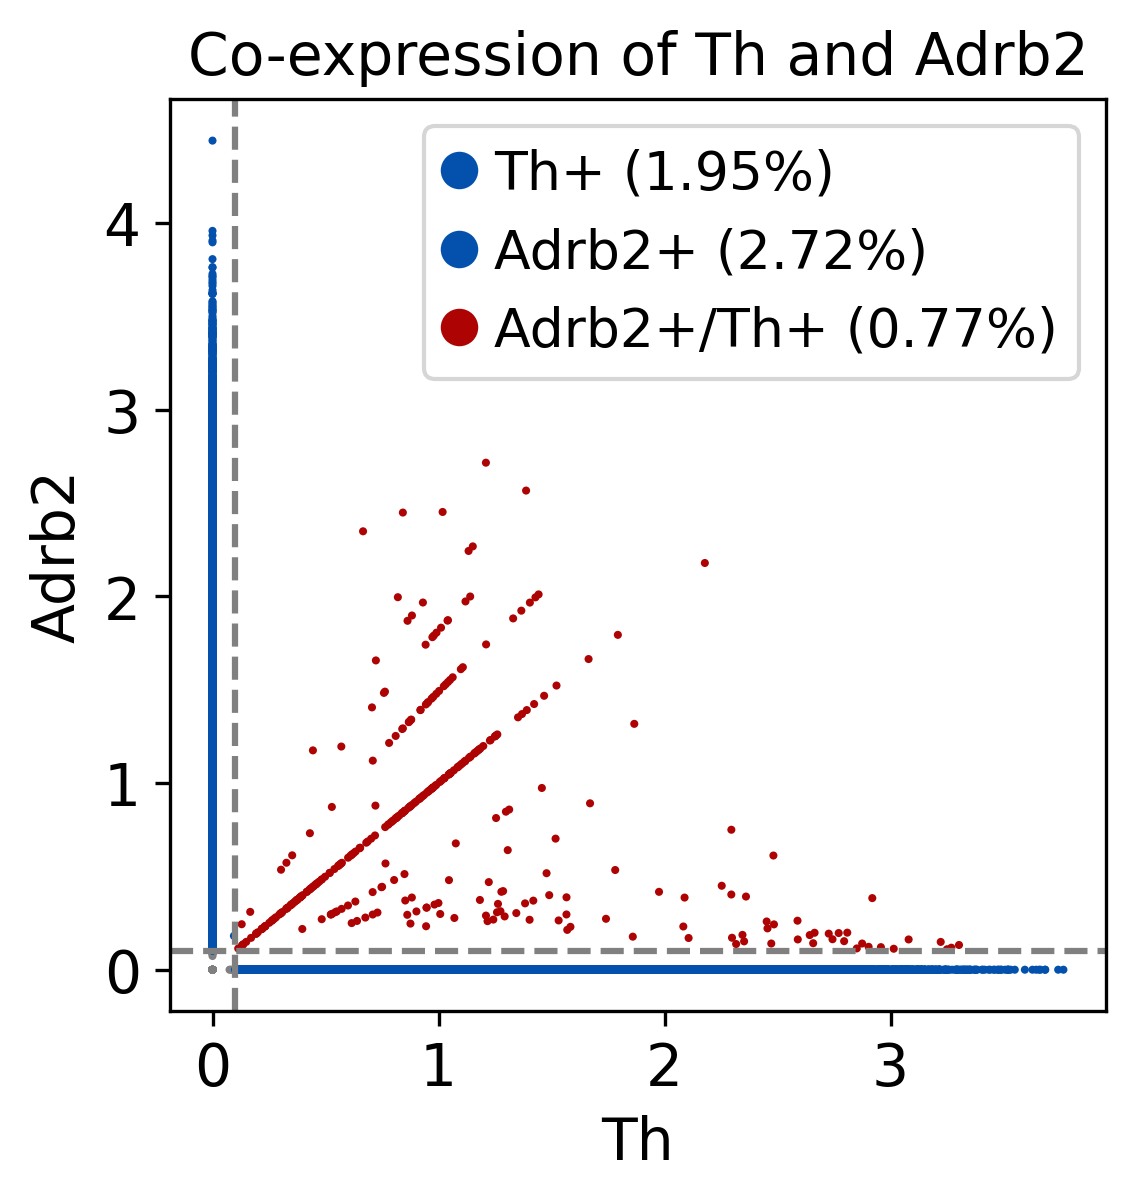

In [ ]:
# Example usage:
fig, ax = plt.subplots()
plot_coexpression_percentage(neurons, 'Th', 'Adrb2', threshold=0.1, ax=ax, plot_legend=False)
plt.show()


In [ ]:
def filter_double_positive(adata, gene1, gene2, threshold=0.5):
    if gene1 not in adata.var_names or gene2 not in adata.var_names:
        raise ValueError(f"One or both genes ({gene1}, {gene2}) not found in adata.var_names.")

    # Extract sparse matrix columns for the genes
    gene1_expr = adata[:, gene1].X
    gene2_expr = adata[:, gene2].X
    
    # Logical mask for both conditions
    mask = (gene1_expr > threshold).multiply(gene2_expr > threshold)
    
    # Subset AnnData
    return adata[mask.toarray().flatten()]


In [ ]:
double_positive = filter_double_positive(adata, 'Th', 'Adrb2', threshold=0.5)
double_positive

View of AnnData object with n_obs × n_vars = 187 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'coexpression'
    var: 'gene_name'
    uns: 'log1p', 'coexpression_colors'

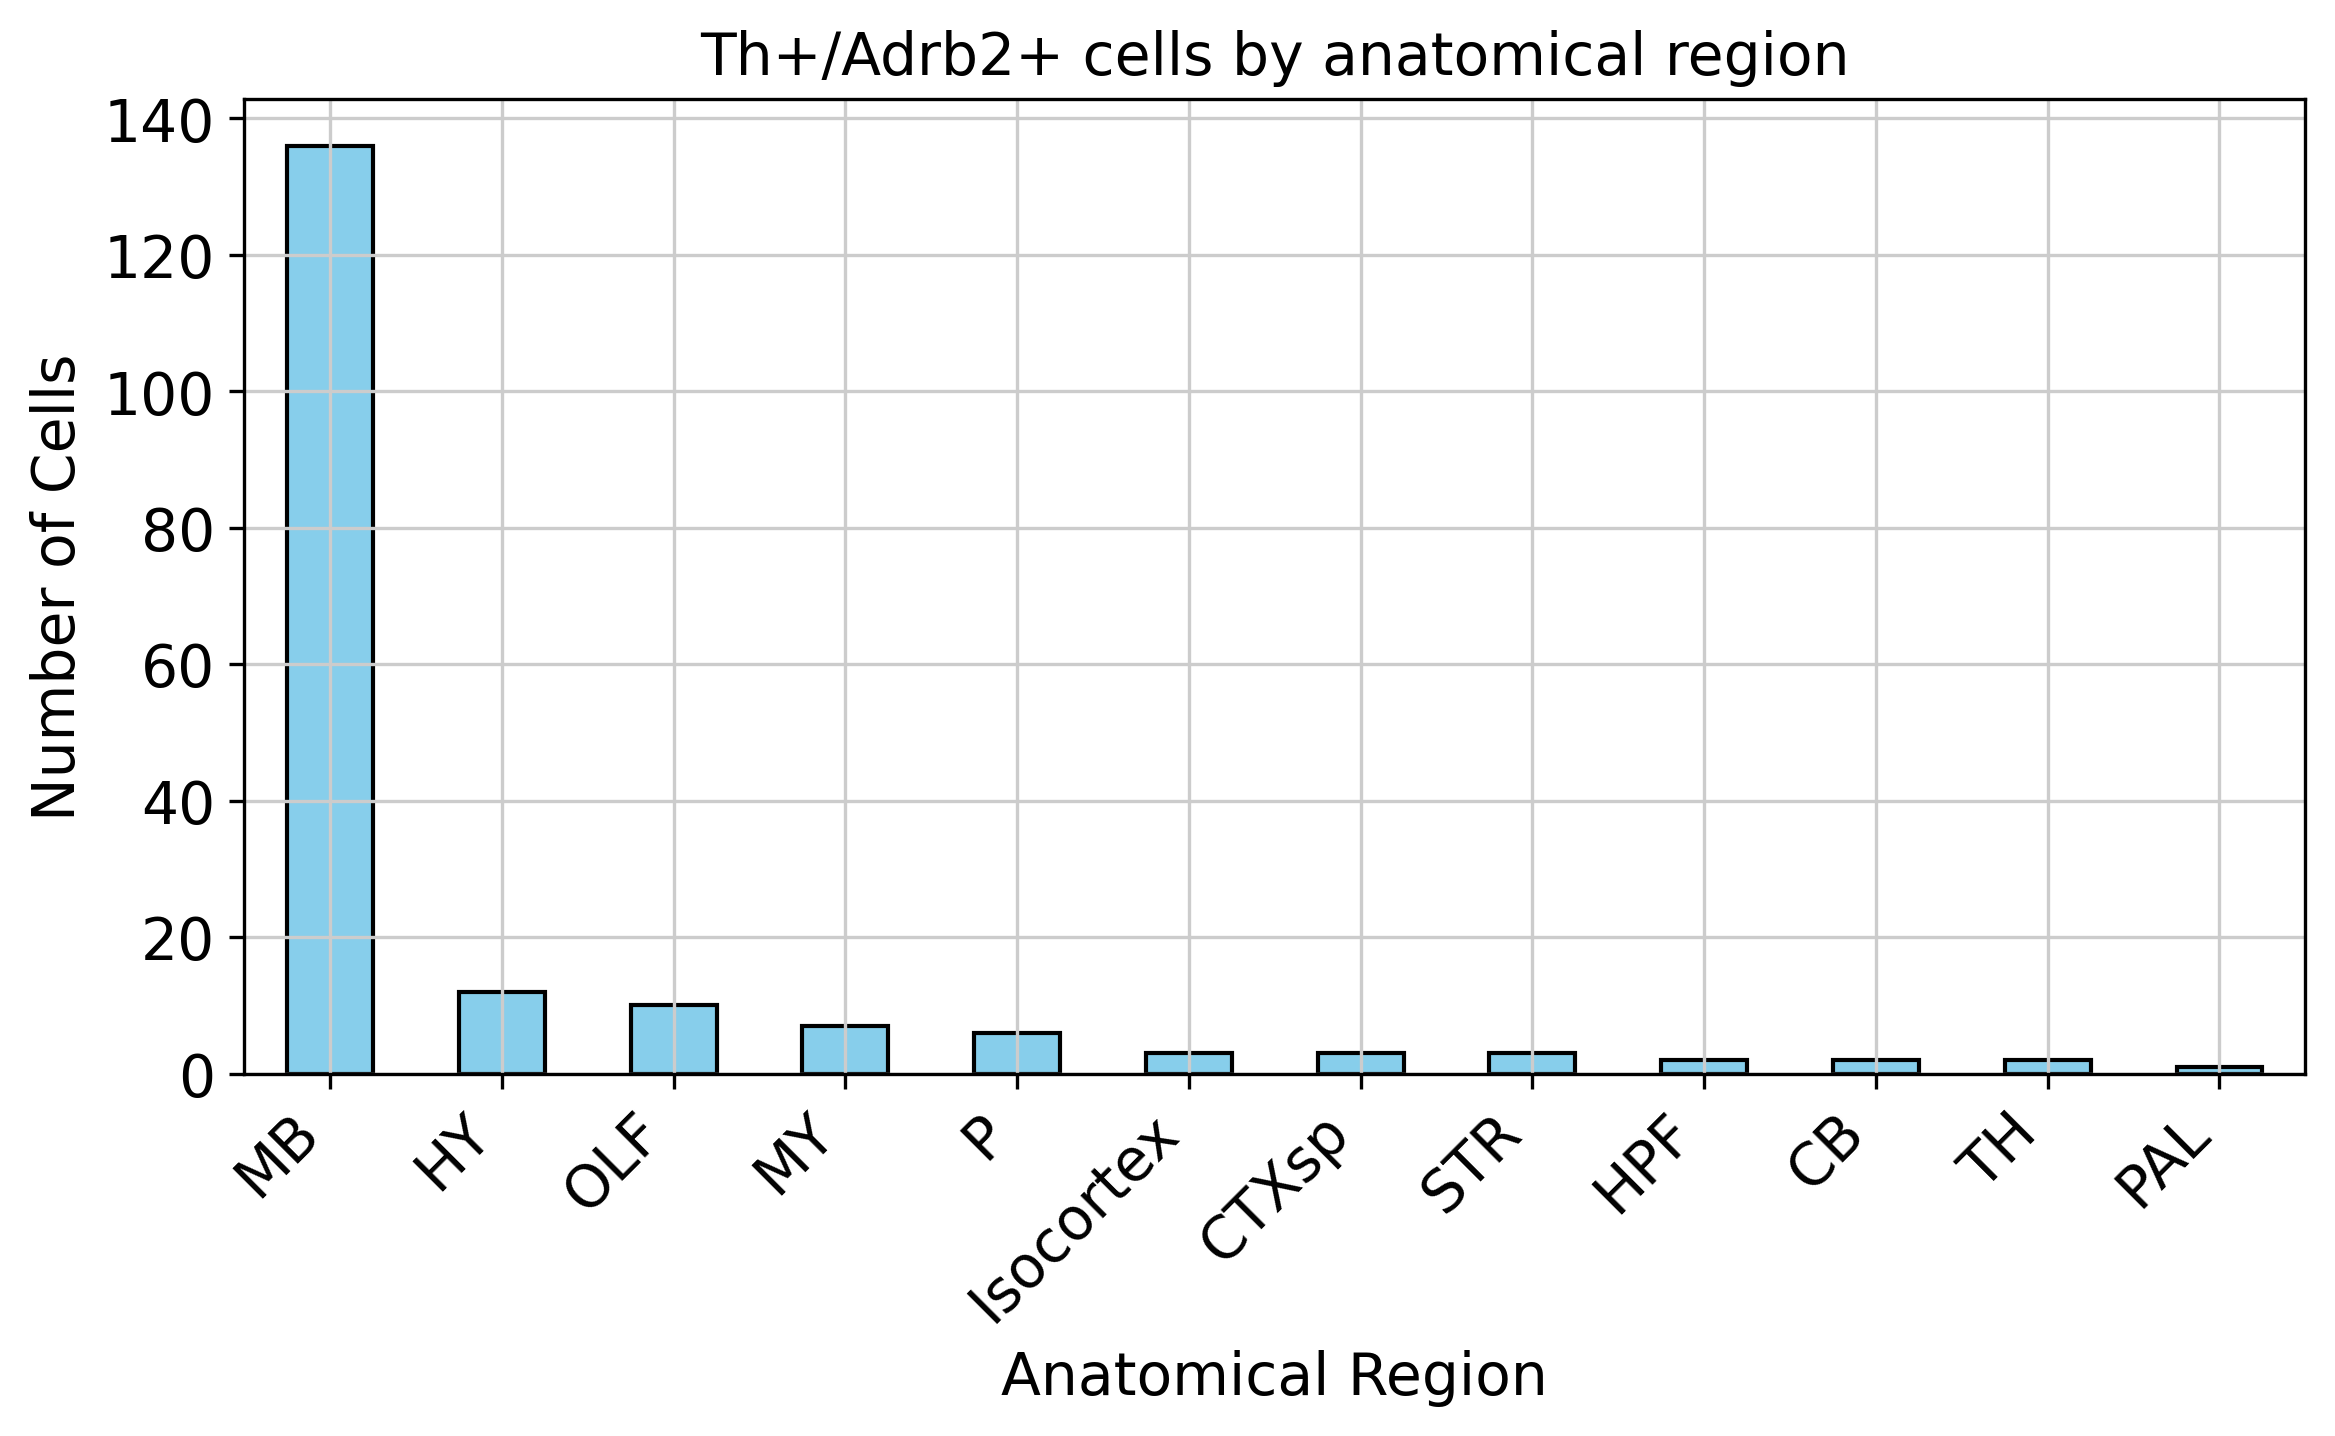

In [ ]:
counts = double_positive.obs['anatomical_division_label'].value_counts()
counts.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8, 5))
plt.title(f"Th+/Adrb2+ cells by anatomical region")
plt.ylabel("Number of Cells")
plt.xlabel("Anatomical Region")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()